In [5]:
import os

os.environ["ROBOFLOW_API_KEY"] = "J1oKKy8ww5yYkJGO3YUZ"


In [6]:
import numpy as np
import supervision as sv
import json
import os
from PIL import Image
import supervision as sv
from rfdetr import RFDETRBase
import cv2
import matplotlib.pyplot as plt
from rfdetr.util.coco_classes import COCO_CLASSES

In [7]:
DATASET_NAME = "aicast_dataset"

# Define your dataset paths
DATASET_ROOT = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR"

# Train paths
train_dir_images = os.path.join(DATASET_ROOT, "AlCastDetection-20251015T171832Z-1-001\\AlCastDetection\\train\\images")
train_dir_labels = os.path.join(DATASET_ROOT, "AlCastDetection-20251015T171832Z-1-001\\AlCastDetection\\train\\labels")  # YOLO format labels
output_train_dir = os.path.join(DATASET_ROOT, "AlCastDetection-20251015T171832Z-1-001\\AlCastDetection\\train")

# Validation paths
valid_dir_images = os.path.join(DATASET_ROOT, "AlCastDetection-20251015T171832Z-1-001\\AlCastDetection\\valid\\images")
valid_dir_labels = os.path.join(DATASET_ROOT, "AlCastDetection-20251015T171832Z-1-001\\AlCastDetection\\valid\\labels")
output_valid_dir = os.path.join(DATASET_ROOT, "AlCastDetection-20251015T171832Z-1-001\\AlCastDetection\\valid")

# Test paths
test_dir_images = os.path.join(DATASET_ROOT, "AlCastDetection-20251015T171832Z-1-001\\AlCastDetection\\test\\images")
test_dir_labels = os.path.join(DATASET_ROOT, "AlCastDetection-20251015T171832Z-1-001\\AlCastDetection\\test\\labels")
output_test_dir = os.path.join(DATASET_ROOT, "AlCastDetection-20251015T171832Z-1-001\\AlCastDetection\\test")


In [4]:
# Define categories for the aquatic dataset
categories = [
    {"id": 0, "name": 'Gas-holes', "supercategory": "Gas-holes"}, 
    {"id": 1, "name": 'shrinkage', "supercategory": "none"}
]
print("Categories defined:")
for cat in categories:
    print(f"  ID {cat['id']}: {cat['name']}")


Categories defined:
  ID 0: Gas-holes
  ID 1: shrinkage


In [5]:
def convert_yolo_to_coco(images_dir, labels_dir, output_dir, categories):
    """
    Convert YOLO format annotations to COCO format
    
    Args:
        images_dir: Directory containing images
        labels_dir: Directory containing YOLO format labels (.txt files)
        output_dir: Directory to save COCO format annotations
        categories: List of category dictionaries
    """
    # Create the COCO format schema
    coco_dataset = {
        "info": {},
        "licenses": [],
        "categories": categories,
        "images": [],
        "annotations": [],
    }
    
    annotation_id = 0
    image_id_counter = 0
    
    # Iterate through all images in the directory
    for image_file in os.listdir(images_dir):
        if not image_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
            
        image_path = os.path.join(images_dir, image_file)
        
        # Open image to get dimensions
        try:
            image = Image.open(image_path)
            width, height = image.size
        except Exception as e:
            print(f"Error opening image {image_file}: {e}")
            continue
        
        image_id = image_id_counter
        
        # Create image dictionary
        image_dict = {
            "id": image_id,
            "width": width,
            "height": height,
            "file_name": image_file,
        }
        
        coco_dataset["images"].append(image_dict)
        
        # Read corresponding YOLO annotation file
        label_file = os.path.splitext(image_file)[0] + ".txt"
        label_path = os.path.join(labels_dir, label_file)
        
        if os.path.exists(label_path):
            try:
                with open(label_path, 'r') as f:
                    annotations = f.readlines()
                
                for ann in annotations:
                    parts = ann.strip().split()
                    if len(parts) < 5:
                        continue
                        
                    category_id = int(parts[0])
                    x, y, w, h = map(float, parts[1:5])
                    
                    # Convert YOLO format (normalized center coordinates) to COCO format (absolute corner coordinates)
                    x_min = int((x - w/2) * width)
                    y_min = int((y - h/2) * height)
                    x_max = int((x + w/2) * width)
                    y_max = int((y + h/2) * height)
                    
                    bbox_width = x_max - x_min
                    bbox_height = y_max - y_min
                    
                    # Create annotation dictionary
                    ann_dict = {
                        "id": annotation_id,
                        "image_id": image_id,
                        "category_id": category_id,
                        "bbox": [x_min, y_min, bbox_width, bbox_height],
                        "area": bbox_height * bbox_width,
                        "iscrowd": 0,
                    }
                    
                    coco_dataset["annotations"].append(ann_dict)
                    annotation_id += 1
            except Exception as e:
                print(f"Error processing label file {label_file}: {e}")
        
        image_id_counter += 1
    
    # Save COCO format annotations
    output_file = os.path.join(output_dir, '_annotations.coco.json')
    with open(output_file, 'w') as f:
        json.dump(coco_dataset, f, indent=2)
    
    print(f"Converted {image_id_counter} images with {annotation_id} annotations")
    print(f"Saved to: {output_file}")
    return coco_dataset

print("Conversion function defined successfully!")


Conversion function defined successfully!


In [6]:
# Convert training set
print("Converting training set...")
train_coco = convert_yolo_to_coco(
    train_dir_images, 
    train_dir_labels, 
    output_train_dir, 
    categories
)

# Convert validation set
print("\nConverting validation set...")
valid_coco = convert_yolo_to_coco(
    valid_dir_images, 
    valid_dir_labels, 
    output_valid_dir, 
    categories
)

# Convert test set
print("\nConverting test set...")
test_coco = convert_yolo_to_coco(
    test_dir_images, 
    test_dir_labels, 
    output_test_dir, 
    categories
)

print("\n✅ All conversions completed!")


Converting training set...
Converted 2427 images with 4094 annotations
Saved to: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\AlCastDetection-20251015T171832Z-1-001\AlCastDetection\train\_annotations.coco.json

Converting validation set...
Converted 681 images with 1127 annotations
Saved to: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\AlCastDetection-20251015T171832Z-1-001\AlCastDetection\valid\_annotations.coco.json

Converting test set...
Converted 346 images with 588 annotations
Saved to: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\AlCastDetection-20251015T171832Z-1-001\AlCastDetection\test\_annotations.coco.json

✅ All conversions completed!


In [7]:
import shutil

def copy_images(source_dir, target_dir):
    """Copy images from source to target directory"""
    os.makedirs(target_dir, exist_ok=True)
    for img_file in os.listdir(source_dir):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            shutil.copy2(
                os.path.join(source_dir, img_file),
                os.path.join(target_dir, img_file)
            )
    print(f"Copied images from {source_dir} to {target_dir}")

# Copy images to COCO format directories
copy_images(train_dir_images, output_train_dir)
copy_images(valid_dir_images, output_valid_dir)
copy_images(test_dir_images, output_test_dir)

print("✅ Image copying completed!")


Copied images from D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\AlCastDetection-20251015T171832Z-1-001\AlCastDetection\train\images to D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\AlCastDetection-20251015T171832Z-1-001\AlCastDetection\train
Copied images from D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\AlCastDetection-20251015T171832Z-1-001\AlCastDetection\valid\images to D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\AlCastDetection-20251015T171832Z-1-001\AlCastDetection\valid
Copied images from D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\AlCastDetection-20251015T171832Z-1-001\AlCastDetection\test\images to D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\AlCastDetection-20251015T171832Z-1-001\AlCastDetection\test
✅ Image copying completed!


In [ ]:
model = RFDETRBase()

DATASET_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\AlCastDetection-20251015T171832Z-1-001\\AlCastDetection"
OUTPUT_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aicast_output"
EPOCHS = 50
BATCH_SIZE = 4  # Adjust based on GPU memory (T4: 4, A100: 16)
GRAD_ACCUM_STEPS = 16  # Keep total batch size = batch_size * grad_accum_steps = 16
LEARNING_RATE = 1e-4

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# History callback to track metrics
history = []

def callback_on_epoch_end(data):
    """Callback function to store training metrics"""
    history.append(data)
    print(f"Epoch {data.get('epoch', 0)}: Train Loss = {data.get('train_loss', 0):.4f}, "
          f"Val Loss = {data.get('test_loss', 0):.4f}, mAP = {data.get('test_map', 0):.4f}")

# Register callback
model.callbacks["on_fit_epoch_end"].append(callback_on_epoch_end)

print("Model initialized and ready for training!")
print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}, Grad Accum: {GRAD_ACCUM_STEPS}")

model.train(
    dataset_dir=DATASET_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    lr=LEARNING_RATE,
    output_dir=OUTPUT_DIR,
    use_ema=True,  # Use Exponential Moving Average for better generalization
    tensorboard=False,  # Set to True if you want TensorBoard logging
    early_stopping=True,  # Enable early stopping
    early_stopping_patience=10,  # Stop if no improvement for 10 epochs
    amp=False,  # **CRITICAL: Disable AMP for CPU training**
    device='cpu',  # Explicitly set device to CPU
    num_workers=0,  # Set to 0 for CPU to avoid multiprocessing issues
    multi_scale=False,  # Disable multi-scale training to avoid inference tensors error
    resolution=448,
)


Loading pretrain weights
Model initialized and ready for training!
Dataset: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\AlCastDetection-20251015T171832Z-1-001\AlCastDetection
Output: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\aicast_output
Epochs: 50, Batch Size: 4, Grad Accum: 16
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=2, grad_accum_steps=16, amp=False, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=50, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes

Epoch: [0]  [ 0/37]  eta: 1:24:49  lr: 0.000100  class_error: 100.00  loss: 15.5065 (15.5065)  loss_ce: 0.4219 (0.4219)  loss_bbox: 1.3747 (1.3747)  loss_giou: 1.6562 (1.6562)  loss_ce_0: 0.3868 (0.3868)  loss_bbox_0: 2.3979 (2.3979)  loss_giou_0: 1.5011 (1.5011)  loss_ce_1: 0.3937 (0.3937)  loss_bbox_1: 1.3768 (1.3768)  loss_giou_1: 1.6469 (1.6469)  loss_ce_enc: 0.3607 (0.3607)  loss_bbox_enc: 2.3609 (2.3609)  loss_giou_enc: 1.6289 (1.6289)  loss_ce_unscaled: 0.4219 (0.4219)  class_error_unscaled: 100.0000 (100.0000)  loss_bbox_unscaled: 0.2749 (0.2749)  loss_giou_unscaled: 0.8281 (0.8281)  cardinality_error_unscaled: 1.2500 (1.2500)  loss_ce_0_unscaled: 0.3868 (0.3868)  loss_bbox_0_unscaled: 0.4796 (0.4796)  loss_giou_0_unscaled: 0.7505 (0.7505)  cardinality_error_0_unscaled: 1.0000 (1.0000)  loss_ce_1_unscaled: 0.3937 (0.3937)  loss_bbox_1_unscaled: 0.2754 (0.2754)  loss_giou_1_unscaled: 0.8234 (0.8234)  cardinality_error_1_unscaled: 4.2500 (4.2500)  loss_ce_enc_unscaled: 0.3607 (0.

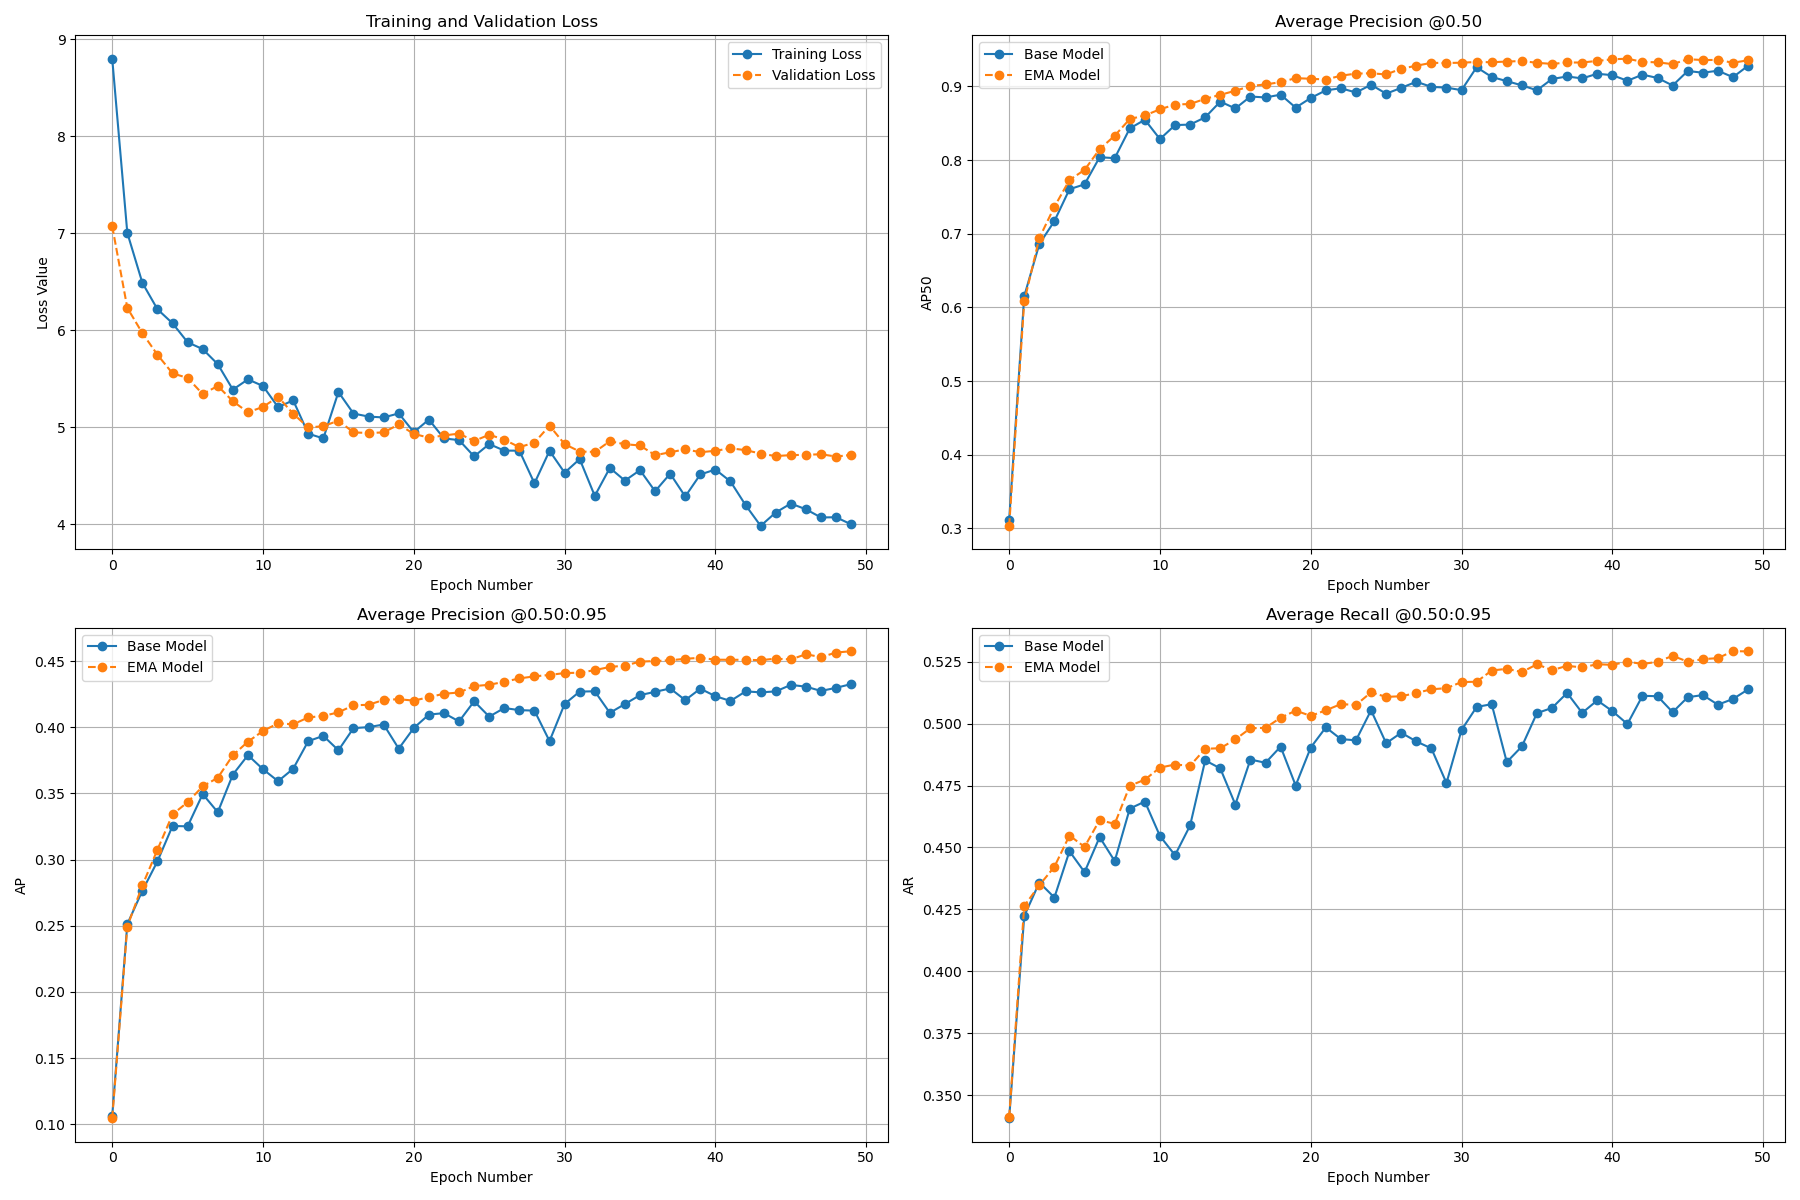

In [17]:
from PIL import Image

Image.open("D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aicast_output\\metrics_plot.png")


In [8]:
model = RFDETRBase(pretrain_weights="D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aicast_output\\checkpoint_best_total.pth")

Loading pretrain weights


In [10]:
import supervision as sv

DATASET_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\AlCastDetection-20251015T171832Z-1-001\\AlCastDetection"
OUTPUT_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aicast_output"

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{DATASET_DIR}/test",
    annotations_path=f"{DATASET_DIR}/test/_annotations.coco.json",
)

In [11]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

model.optimize_for_inference()
targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    # Open and convert image to RGB (ensures 3 channels)
    image = Image.open(path).convert('RGB')  # This fixes the channel issue
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)


`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.
100%|██████████| 346/346 [02:42<00:00,  2.12it/s]


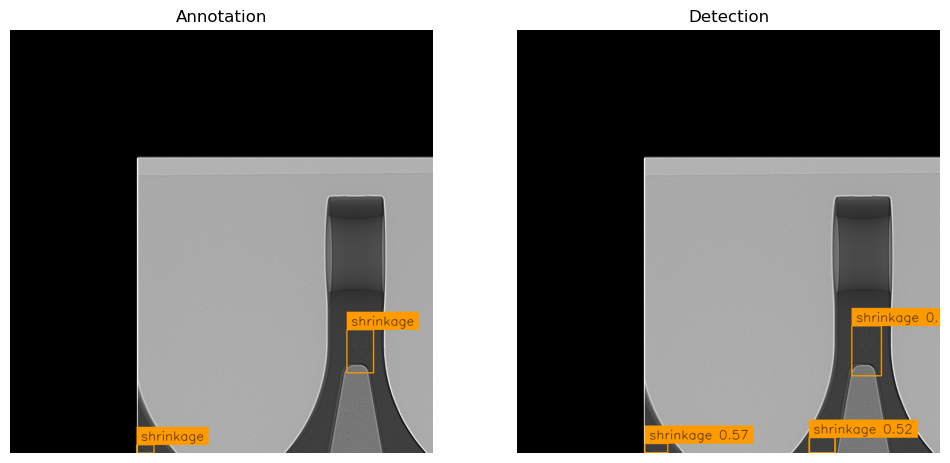

In [12]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])